## 1. GİRİŞ VE PROBLEM TANIMI

* **Problemin Tanımı ve Önemi:** Bu projede, bankacılık sektöründe sıkça karşılaşılan bir sınıflandırma problemini ele almaktayız. Temel amacımız, banka tarafından yürütülen doğrudan pazarlama kampanyalarında (özellikle telefon aramalarında), müşterilerin kampanyaya olumlu dönüş yapıp yapmayacağını önceden tahmin etmektir. Çalışmada modelimizin tahmin etmeye çalışacağı hedef değişken, veri setinde yer alan deposit (evet/hayır) sütunudur.

* **Veri Setinin Kaynağı ve İçeriği:** Veri seti Kaggle platformundan "Bank Marketing Dataset" başlığı altında temin edilmiştir. 11.162 örnek (satır) ve 17 özellikten (sütun) oluşmaktadır. Veri setinde müşterilerin yaşı, mesleği, eğitim durumu, bankadaki bakiye miktarı gibi demografik ve finansal bilgilerin yanı sıra; kampanya sırasındaki son temas süresi ve önceki kampanyaların sonuçları gibi operasyonel veriler yer almaktadır.

* **Makine Öğrenimi Uygulama Motivasyonu:** Doğrudan pazarlama süreçlerinde rastgele müşteri seçimi, yüksek maliyet ve düşük verimlilikle sonuçlanmaktadır. Bu problemde makine öğrenimi algoritmalarının kullanılmasının temel motivasyonu, geniş veri kümeleri içindeki karmaşık müşteri davranış örüntülerini tespit ederek bankanın kaynaklarını doğru müşterilere yönlendirmesini sağlamaktır. Böylece pazarlama stratejileri veri odaklı hale getirilerek başarı oranları artırılabilir.

In [1]:
%%capture
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost optuna # Gerekli kütüphanelerin kurulumu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Veriyi okuma 
try:
    df = pd.read_csv('bank.csv', sep=',')
    if len(df.columns) == 1:
        df = pd.read_csv('bank.csv', sep=';')
except FileNotFoundError:
    print("Hata: bank.csv dosyası bulunamadı!")

df.columns = df.columns.str.strip()

print("Veri Seti başarıyla yüklendi")

Veri Seti başarıyla yüklendi


## 2. KİŞİSEL VERİ ANALİZİ (EDA)

Bu bölümde veri setinin genel yapısını, eksik değerleri ve sayısal değişkenlerin temel istatistiksel özetlerini inceleyeceğiz.

In [3]:
# Veri seti hakkında genel bilgi (sütun tipleri ve bellek kullanımı)
print("--- Veri Bilgisi ---")
df.info()

# Sayısal değişkenlerin istatistiksel özeti (ortalama, medyan, standart sapma vb.)
print("\n--- Temel İstatistikler ---")
display(df.describe())

# Eksik değer kontrolü
print("\n--- Eksik Değer Sayısı ---")
print(df.isnull().sum())

--- Veri Bilgisi ---
<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB

--- Temel İstatistikler ---


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000



--- Eksik Değer Sayısı ---
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


* **Hedef Değişken Dağılımı:** Hedef değişkenimiz olan 'deposit' sütununun sınıflar arasındaki dağılımını (denge durumunu) kontrol ediyoruz. (Yes=5289, No=5873)

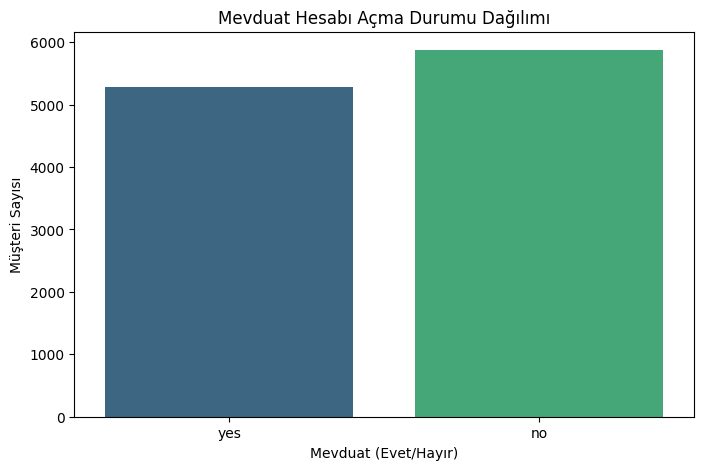

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

PLOT_WIDTH = 8
PLOT_HEIGHT = 5

def plot_deposit_distribution(data):
    """Hedef değişkenin dağılımını çubuk grafik ile gösterir."""
    plt.figure(figsize=(PLOT_WIDTH, PLOT_HEIGHT))
    sns.countplot(x='deposit', data=data, palette='viridis')
    plt.title('Mevduat Hesabı Açma Durumu Dağılımı')
    plt.xlabel('Mevduat (Evet/Hayır)')
    plt.ylabel('Müşteri Sayısı')
    plt.show()

plot_deposit_distribution(df)

* **Korelasyon Matrisi:** Sayısal değişkenler arasındaki ilişkileri ve birbirleriyle olan korelasyonlarını ısı haritası (heatmap) üzerinden inceliyoruz.

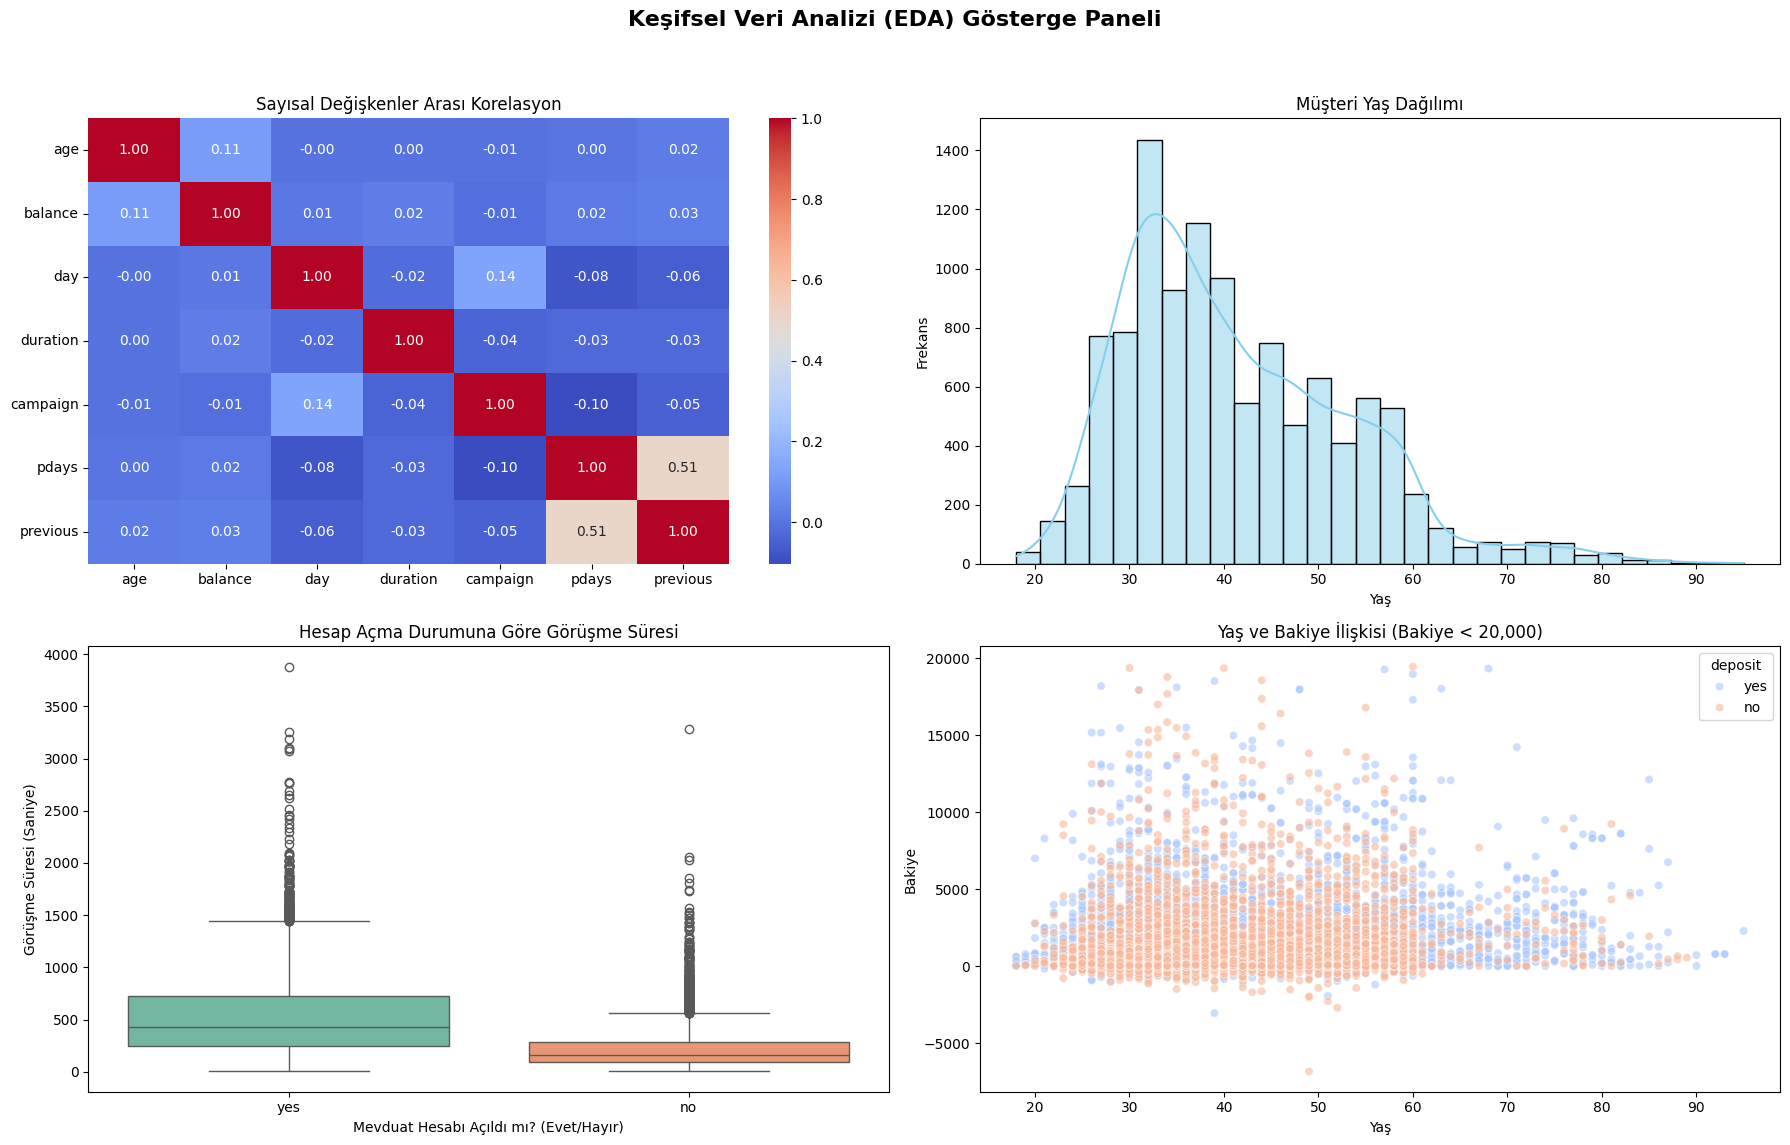

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sabitler (Constants)
DASHBOARD_WIDTH = 18
DASHBOARD_HEIGHT = 12
SCATTER_MAX_BALANCE = 20000
TITLE_FONT_SIZE = 16
HISTOGRAM_BINS = 30
SCATTER_ALPHA = 0.6
LAYOUT_MARGINS = [0, 0.03, 1, 0.95]

def plot_eda_dashboard(data):

    fig, axes = plt.subplots(2, 2, figsize=(DASHBOARD_WIDTH, DASHBOARD_HEIGHT))
    fig.suptitle('Keşifsel Veri Analizi (EDA) Gösterge Paneli', fontsize=TITLE_FONT_SIZE, fontweight='bold')

    # 1. Grafik (Sol Üst): Korelasyon Matrisi
    numeric_df = data.select_dtypes(include=['int64', 'float64'])
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0, 0])
    axes[0, 0].set_title('Sayısal Değişkenler Arası Korelasyon')

    # 2. Grafik (Sağ Üst): Yaş Dağılımı
    sns.histplot(data['age'], bins=HISTOGRAM_BINS, kde=True, color='skyblue', ax=axes[0, 1])
    axes[0, 1].set_title('Müşteri Yaş Dağılımı')
    axes[0, 1].set_xlabel('Yaş')
    axes[0, 1].set_ylabel('Frekans')

    # 3. Grafik (Sol Alt): Süre ve Mevduat İlişkisi (Boxplot)
    sns.boxplot(x='deposit', y='duration', data=data, palette='Set2', ax=axes[1, 0])
    axes[1, 0].set_title('Hesap Açma Durumuna Göre Görüşme Süresi')
    axes[1, 0].set_xlabel('Mevduat Hesabı Açıldı mı? (Evet/Hayır)')
    axes[1, 0].set_ylabel('Görüşme Süresi (Saniye)')

    # 4. Grafik (Sağ Alt): Yaş ve Bakiye İlişkisi (Scatter Plot)
    filtered_data = data[data['balance'] < SCATTER_MAX_BALANCE]
    sns.scatterplot(x='age', y='balance', hue='deposit', data=filtered_data, alpha=SCATTER_ALPHA, palette='coolwarm', ax=axes[1, 1])
    
    axes[1, 1].set_title(f'Yaş ve Bakiye İlişkisi (Bakiye < {SCATTER_MAX_BALANCE:,})') 
    axes[1, 1].set_xlabel('Yaş')
    axes[1, 1].set_ylabel('Bakiye')

    plt.tight_layout(rect=LAYOUT_MARGINS)
    plt.show()

plot_eda_dashboard(df)

* **EDA Sonucu Elde Edilen İçgörüler:**  Hedef değişkenimiz olan `deposit` sınıflarının (evet/hayır) veri setinde birbirine çok yakın olduğu, bu nedenle dengesiz veri problemi (imbalanced data) yaşanmayacağı tespit edilmiştir. Ayrıca veri setinde hiçbir eksik (null) değere rastlanmamıştır. Grafikleri incelediğimizde pdays ve previous sütunları arasında doğrusal bir bağıntı olduğunu ve görüşme süresinin mevduat hesabı açımına olumlu etki ettiğini görebiliriz.

## 3. Veri Önişleme ve Özellik Mühendisliği
Bu aşamada model eğitiminden önce veriyi makine öğrenimi algoritmalarının anlayabileceği formata getirmek için gerekli dönüşümler yapılmıştır:

* **Eksik Veri Stratejisi:** EDA aşamasında veri setinde hiçbir eksik (null) değer bulunmadığı tespit edilmiştir. Bu nedenle herhangi bir silme veya doldurma (imputation) işlemine gerek duyulmamıştır.
* **Özellik Mühendisliği (+Bonus):** Veri setindeki `pdays` (önceki kampanyadan bu yana geçen günde en son ne zaman iletişim kuruldu) değişkeninde -1 değeri, müşterinin daha önce hiç aranmadığını göstermektedir. Modelin bu durumu daha iyi öğrenebilmesi için `is_previously_contacted` (daha önce arandı mı?) adında ikili (1/0) yeni bir özellik türetilmiştir. Hedef değişken olan `deposit` ise 'yes'=1, 'no'=0 olacak şekilde kodlanmıştır.
* **Veri Bölme (Train/Validation/Test):** Yönergeye uygun olarak veri seti veri sızıntısını önlemek amacıyla önce **%60 Eğitim (Train)**, **%20 Doğrulama (Validation)** ve **%20 Test** olarak üç parçaya ayrılmıştır. Hedef sınıfın dengesini korumak için `stratify` parametresi kullanılmıştır.
* **Ölçekleme ve Kodlama (Scaling & Encoding):** Sayısal değişkenler için, özellikle Lojistik Regresyon ve SVM gibi ölçeğe duyarlı algoritmalarda performansı iyileştirmek amacıyla StandardScaler kullanılabilir. Kategorik değişkenler için ise algoritmaların bu verileri işleyebilmesi amacıyla One-Hot Encoding uygulanacaktır. Ağaç tabanlı modeller olan Random Forest ve XGBoost ölçeklemeden doğrudan etkilenmemekle birlikte, kategorik değişkenlerin sayısal forma dönüştürülmesi yine gereklidir.

In [6]:
from sklearn.model_selection import train_test_split

# Sabitler (Constants)
TEMP_SIZE = 0.40  
VAL_TEST_SPLIT = 0.50 
RANDOM_SEED = 42
NOT_CONTACTED_PDAYS = -1 
TARGET_YES_VALUE = 'yes' 

def feature_engineering(data):
    """
    Veri setine yeni özellikler ekler ve hedef değişkeni sayısallaştırır.
    """
    df_processed = data.copy()
    
    df_processed['deposit'] = df_processed['deposit'].apply(lambda x: 1 if x == TARGET_YES_VALUE else 0)
    
    df_processed['is_previously_contacted'] = df_processed['pdays'].apply(lambda x: 0 if x == NOT_CONTACTED_PDAYS else 1)
    
    return df_processed

# Özellik mühendisliği fonksiyonunu uygulama
df_engineered = feature_engineering(df)

X = df_engineered.drop('deposit', axis=1) 
y = df_engineered['deposit']

# 1. Aşama: Veriyi Eğitim ve Geçici (Validation + Test) olarak bölme
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=TEMP_SIZE, random_state=RANDOM_SEED, stratify=y
)

# 2. Aşama: Geçici veriyi Validation ve Test olarak ikiye bölme
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=VAL_TEST_SPLIT, random_state=RANDOM_SEED, stratify=y_temp
)

train_pct = int((1 - TEMP_SIZE) * 100)
val_pct = int((TEMP_SIZE * (1 - VAL_TEST_SPLIT)) * 100)
test_pct = int((TEMP_SIZE * VAL_TEST_SPLIT) * 100)

print(f"Toplam Veri Sayısı: {len(X)}")
print(f"Train Seti (%{train_pct})   : {len(X_train)} satır")
print(f"Validation Seti (%{val_pct}): {len(X_val)} satır")
print(f"Test Seti (%{test_pct})      : {len(X_test)} satır")

Toplam Veri Sayısı: 11162
Train Seti (%60)   : 6697 satır
Validation Seti (%20): 2232 satır
Test Seti (%20)      : 2233 satır


* **Veri Sızıntısını (Data Leakage) Önleme:**
Makine öğrenimi modellerinin başarısını gerçekçi ölçebilmek için, scaler (ölçekleyici) ve encoder (kodlayıcı) gibi dönüşüm işlemleri bir `ColumnTransformer` (boru hattı) içerisinde tanımlanmıştır. Bu dönüştürücüler sadece Eğitim verisi üzerinden öğrenilecek (fit), Validation ve Test verilerine ise sadece uygulanacaktır (transform).

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

print("Kategorik Sütunlar (One-Hot Encoder uygulanacak):", cat_cols)
print("Sayısal Sütunlar (StandardScaler uygulanacak):", num_cols)

Kategorik Sütunlar (One-Hot Encoder uygulanacak): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Sayısal Sütunlar (StandardScaler uygulanacak): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'is_previously_contacted']


## 4 Model Eğitimi ve Hiperparametre Optimizasyonu

Bu bölümde üç farklı algoritma eğitilecektir:
1. **Logistic Regression:** Temel (Baseline) model olarak kullanılacaktır.
2. **Random Forest:** Ağaç tabanlı topluluk (ensemble) modeli olarak değerlendirilecektir.
3. **XGBoost:** Gelişmiş boosting modeli olarak kullanılacaktır.

Modeller öncelikle varsayılan (default) parametrelerle eğitilecek, ardından performanslarını artırmak için hiperparametre optimizasyonu uygulanacaktır. Random Forest için **GridSearchCV**, XGBoost için ise **Optuna** (+Bonus Puan) kullanılacaktır.

### Hiperparametre Arama Uzayı

| Model | Optimizasyon Yöntemi | Hiperparametre | Arama Uzayı / Değerler | Gerekçe |
| :--- | :--- | :--- | :--- | :--- |
| **Random Forest** | GridSearchCV | `n_estimators` | [100, 200] | Ağaç sayısını artırmak ezberlemeyi (overfitting) azaltabilir. |
| | | `max_depth` | [None, 10, 20] | Ağaç derinliğini sınırlandırmak modelin genellenebilirliğini artırır. |
| | | `min_samples_split`| [2, 5] | Bölünme için gereken minimum örnek sayısı. |
| **XGBoost** | Optuna (Bayesian) | `n_estimators` | 50 - 300 (int) | Boosting tur sayısının optimal noktasını bulmak. |
| | | `max_depth` | 3 - 9 (int) | Karmaşıklığı kontrol etmek. |
| | | `learning_rate` | 0.01 - 0.3 (float, log) | Öğrenme hızı ile ağaç sayısı arasındaki dengeyi kurmak. |

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
import time

# Sabitler ve Hiperparametreler
RANDOM_SEED = 42
CV_FOLDS = 5
LR_MAX_ITER = 1000

COL_W_NAME = 32
COL_W_TIME = 9
COL_W_ACC = 8
COL_W_PREC = 9
COL_W_REC = 8
COL_W_F1 = 8

TABLE_WIDTH = COL_W_NAME + COL_W_TIME + COL_W_ACC + COL_W_PREC + COL_W_REC + COL_W_F1 + 15

# 1. VARSAYILAN (DEFAULT) MODELLERİN TANIMLANMASI
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=LR_MAX_ITER))])
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=RANDOM_SEED))])
pipeline_xgb = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss'))])

def evaluate_baseline_models(pipelines_dict, X_train_data, y_train_data, X_val_data, y_val_data):
    """
    Modelleri eğitir; Eğitim Süresi, Accuracy, Precision, Recall ve F1 skorlarını tablo halinde raporlar.
    """
    print("--- Varsayılan (Default) Model Performansları (Validation Seti) ---")
    
    print(f"{'Model Adı':<{COL_W_NAME}} | {'Süre (sn)':<{COL_W_TIME}} | {'Accuracy':<{COL_W_ACC}} | {'Precision':<{COL_W_PREC}} | {'Recall':<{COL_W_REC}} | {'F1 Score':<{COL_W_F1}}")
    print("-" * TABLE_WIDTH)

    for name, pipeline in pipelines_dict.items():
        
        start_time = time.time()
        pipeline.fit(X_train_data, y_train_data)
        end_time = time.time()
        
        training_time = end_time - start_time

        y_pred = pipeline.predict(X_val_data)

        accuracy = accuracy_score(y_val_data, y_pred)
        precision = precision_score(y_val_data, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_val_data, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_val_data, y_pred, average='weighted', zero_division=0)

        print(f"{name:<{COL_W_NAME}} | {training_time:<{COL_W_TIME}.4f} | {accuracy:<{COL_W_ACC}.4f} | {precision:<{COL_W_PREC}.4f} | {recall:<{COL_W_REC}.4f} | {f1:<{COL_W_F1}.4f}")

# Varsayılan modelleri test etme
models = {
    'Logistic Regression (Baseline)': pipeline_lr,
    'Random Forest': pipeline_rf,
    'XGBoost': pipeline_xgb
}

evaluate_baseline_models(models, X_train, y_train, X_val, y_val)

--- Varsayılan (Default) Model Performansları (Validation Seti) ---
Model Adı                        | Süre (sn) | Accuracy | Precision | Recall   | F1 Score
-----------------------------------------------------------------------------------------
Logistic Regression (Baseline)   | 0.0688    | 0.8320   | 0.8319    | 0.8320   | 0.8319  
Random Forest                    | 0.8820    | 0.8571   | 0.8584    | 0.8571   | 0.8572  
XGBoost                          | 0.4106    | 0.8593   | 0.8604    | 0.8593   | 0.8594  


Varsayılan model sonuçları incelendiğinde, temel modelimizin üzerine çıkabildiğimizi görüyoruz. Şimdi **GridSearchCV** kullanarak Random Forest modelini, **Optuna** kullanarak ise XGBoost modelini optimize edeceğiz.

In [9]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import optuna
import time

# --- KONFİGÜRASYON VE SABİTLER (CONSTANTS) ---

# Optuna Ayarları
OPTUNA_N_TRIALS = 50

COL_W_NAME = 32
COL_W_TIME = 9
COL_W_ACC = 8
COL_W_PREC = 9
COL_W_REC = 8
COL_W_F1 = 8
TABLE_WIDTH = COL_W_NAME + COL_W_TIME + COL_W_ACC + COL_W_PREC + COL_W_REC + COL_W_F1 + 15

RF_PARAM_GRID = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

XGB_N_ESTIMATORS_BOUNDS = (50, 300)
XGB_MAX_DEPTH_BOUNDS = (3, 9)
XGB_LEARNING_RATE_BOUNDS = (0.01, 0.3)

def evaluate_and_print_row(model_name, pipeline, X_train_data, y_train_data, X_val_data, y_val_data):
    start_time = time.time()
    pipeline.fit(X_train_data, y_train_data)
    end_time = time.time()
    
    training_time = end_time - start_time
    y_pred = pipeline.predict(X_val_data)
    
    accuracy = accuracy_score(y_val_data, y_pred)
    precision = precision_score(y_val_data, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_val_data, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val_data, y_pred, average='weighted', zero_division=0)
    
    print(f"{model_name:<{COL_W_NAME}} | {training_time:<{COL_W_TIME}.4f} | {accuracy:<{COL_W_ACC}.4f} | {precision:<{COL_W_PREC}.4f} | {recall:<{COL_W_REC}.4f} | {f1:<{COL_W_F1}.4f}")

# --- 2. RANDOM FOREST İÇİN GRIDSEARCHCV ---
print("Random Forest optimize ediliyor...")

grid_search_rf = GridSearchCV(pipeline_rf, RF_PARAM_GRID, cv=CV_FOLDS, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print(f"-> Random Forest En İyi Parametreler: {grid_search_rf.best_params_}")
print(f"-> Random Forest En İyi CV Skoru (Eğitim): {grid_search_rf.best_score_:.4f}\n")


# --- 3. XGBOOST İÇİN OPTUNA ---
print("XGBoost optimize ediliyor...")
def objective(trial):
   
    optuna_params = {
        'classifier__n_estimators': trial.suggest_int('classifier__n_estimators', *XGB_N_ESTIMATORS_BOUNDS),
        'classifier__max_depth': trial.suggest_int('classifier__max_depth', *XGB_MAX_DEPTH_BOUNDS),
        'classifier__learning_rate': trial.suggest_float('classifier__learning_rate', *XGB_LEARNING_RATE_BOUNDS, log=True)
    }
    
    xgb_opt_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor), 
        ('classifier', XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss'))
    ])
    xgb_opt_pipeline.set_params(**optuna_params)
    
    return cross_val_score(xgb_opt_pipeline, X_train, y_train, cv=CV_FOLDS, scoring='accuracy', n_jobs=-1).mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=OPTUNA_N_TRIALS)

print(f"-> XGBoost En İyi Parametreler (Optuna): {study.best_params}")
print(f"-> XGBoost En İyi CV Skoru (Eğitim): {study.best_value:.4f}\n")

best_xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss', **study.best_params))
])

print("=" * TABLE_WIDTH)
print("--- Optimize Edilmiş Model Performansları (Validation Seti) ---")
print(f"{'Model Adı':<{COL_W_NAME}} | {'Süre (sn)':<{COL_W_TIME}} | {'Accuracy':<{COL_W_ACC}} | {'Precision':<{COL_W_PREC}} | {'Recall':<{COL_W_REC}} | {'F1 Score':<{COL_W_F1}}")
print("-" * TABLE_WIDTH)

evaluate_and_print_row('Random Forest (Tuned)', grid_search_rf.best_estimator_, X_train, y_train, X_val, y_val)
evaluate_and_print_row('XGBoost (Optuna Tuned)', best_xgb_pipeline, X_train, y_train, X_val, y_val)

print("=" * TABLE_WIDTH)

Random Forest optimize ediliyor...
-> Random Forest En İyi Parametreler: {'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
-> Random Forest En İyi CV Skoru (Eğitim): 0.8495

XGBoost optimize ediliyor...
-> XGBoost En İyi Parametreler (Optuna): {'classifier__n_estimators': 139, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.11975005095582858}
-> XGBoost En İyi CV Skoru (Eğitim): 0.8546

--- Optimize Edilmiş Model Performansları (Validation Seti) ---
Model Adı                        | Süre (sn) | Accuracy | Precision | Recall   | F1 Score
-----------------------------------------------------------------------------------------
Random Forest (Tuned)            | 1.5988    | 0.8589   | 0.8614    | 0.8589   | 0.8589  
XGBoost (Optuna Tuned)           | 0.1785    | 0.8593   | 0.8604    | 0.8593   | 0.8594  


Optimizasyon süreçleri sonucunda elde edilen en iyi parametrelerle, nihai (tuned) Random Forest ve XGBoost modelleri eğitim seti üzerinde yeniden eğitilmiş ve değerlendirilmeye hazır hale getirilmiştir.

In [10]:
# --- 4. NİHAİ MODELLERİN EĞİTİLMESİ ---

best_rf_model = grid_search_rf.best_estimator_

final_xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss'))
])
final_xgb_pipeline.set_params(**study.best_params)

final_xgb_pipeline.fit(X_train, y_train)

print("Nihai (Tuned) modeller başarıyla eğitildi.")

Nihai (Tuned) modeller başarıyla eğitildi.


## 5. Model Karşılaştırma ve Değerlendirme

Bu bölümde eğittiğimiz temel (baseline), varsayılan (default) ve optimize edilmiş (tuned) modellerin performansları **Test Seti** üzerinde karşılaştırılmıştır. Sınıflandırma başarısını ölçmek için Accuracy, Precision, Recall ve F1-Score metrikleri kullanılmıştır. 



In [11]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

DECIMAL_PRECISION = 4
ZERO_DIV_BEHAVIOR = 0

def evaluate_models(models_dict, X_test_data, y_test_data):
    """
    Sözlük içindeki tüm modellerin metriklerini hesaplar ve bir karşılaştırma tablosu döndürür.
    """
    results = []
    
    for name, model in models_dict.items():
        
        start_time = time.time()
        y_pred = model.predict(X_test_data)
        prediction_time = time.time() - start_time
      
        acc = accuracy_score(y_test_data, y_pred)
        prec = precision_score(y_test_data, y_pred, zero_division=ZERO_DIV_BEHAVIOR)
        rec = recall_score(y_test_data, y_pred, zero_division=ZERO_DIV_BEHAVIOR)
        f1 = f1_score(y_test_data, y_pred, zero_division=ZERO_DIV_BEHAVIOR)
        
        results.append({
            'Model': name,
            'Accuracy': f"{acc:.{DECIMAL_PRECISION}f}",
            'Precision': f"{prec:.{DECIMAL_PRECISION}f}",
            'Recall': f"{rec:.{DECIMAL_PRECISION}f}",
            'F1-Score': f"{f1:.{DECIMAL_PRECISION}f}",
            'Tahmin Süresi (sn)': f"{prediction_time:.{DECIMAL_PRECISION}f}"
        })
        
    return pd.DataFrame(results)

final_models = {
    'Baseline (Logistic Reg)': pipeline_lr,
    'Random Forest (Default)': pipeline_rf,
    'Random Forest (Tuned)': best_rf_model,
    'XGBoost (Default)': pipeline_xgb,
    'XGBoost (Tuned)': final_xgb_pipeline
}

comparison_df = evaluate_models(final_models, X_test, y_test)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score,Tahmin Süresi (sn)
0,Baseline (Logistic Reg),0.8222,0.8282,0.7883,0.8077,0.0122
1,Random Forest (Default),0.8549,0.8271,0.8771,0.8514,0.0684
2,Random Forest (Tuned),0.8522,0.8199,0.8819,0.8497,0.0867
3,XGBoost (Default),0.8513,0.8330,0.8582,0.8454,0.0099
4,XGBoost (Tuned),0.8616,0.8414,0.8724,0.8566,0.0133


Yukarıdaki metrik tablosuna ek olarak modellerin hatalarını, sınıflandırma ayrım güçlerini (ROC-AUC) ve modele en çok etki eden özellikleri (Feature Importance) görselleştiriyoruz.

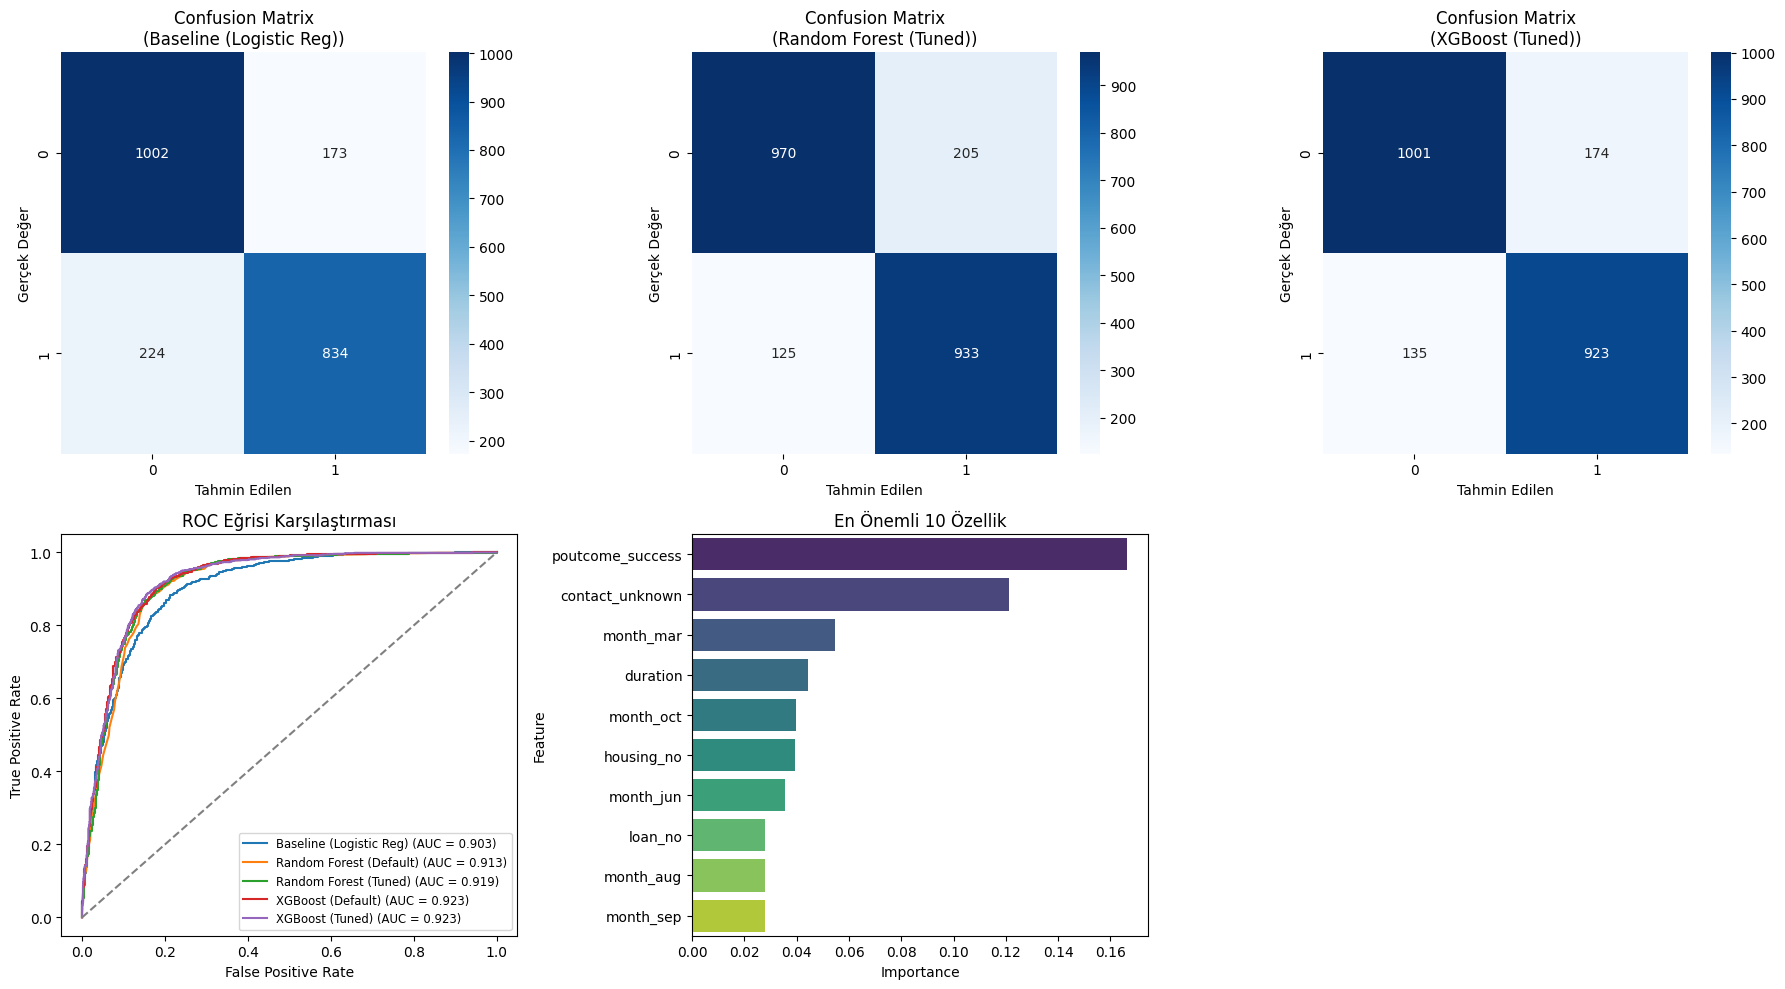

In [12]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

EVAL_PLOT_WIDTH = 18
EVAL_PLOT_HEIGHT = 10 
TOP_N_FEATURES = 10
AUC_DECIMAL_PRECISION = 3
POSITIVE_CLASS_INDEX = 1

CM_MODELS_TO_PLOT = ['Baseline (Logistic Reg)', 'Random Forest (Tuned)', 'XGBoost (Tuned)']

def plot_all_evaluation_charts(models_dict, best_model, X_test_data, y_test_data, cat_columns_list, num_columns_list):
    """Tüm ana modellerin Karmaşıklık Matrislerini, ROC Eğrisini ve Özellik Önemini 2x3 panoda çizer."""
    
    fig, axes = plt.subplots(2, 3, figsize=(EVAL_PLOT_WIDTH, EVAL_PLOT_HEIGHT))
    
    # --- 1. SATIR: CONFUSION MATRIX'LER ---
    for i, model_name in enumerate(CM_MODELS_TO_PLOT):
      
        if model_name in models_dict:
            model = models_dict[model_name]
            y_pred = model.predict(X_test_data)
            cm = confusion_matrix(y_test_data, y_pred)
            
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, i])
            axes[0, i].set_title(f'Confusion Matrix\n({model_name})')
            axes[0, i].set_xlabel('Tahmin Edilen')
            axes[0, i].set_ylabel('Gerçek Değer')

    # --- 2. SATIR - SOL: ROC EĞRİSİ ---
    for name, model in models_dict.items():
        if hasattr(model, "predict_proba"):
          
            y_prob = model.predict_proba(X_test_data)[:, POSITIVE_CLASS_INDEX]
            fpr, tpr, _ = roc_curve(y_test_data, y_prob)
            roc_auc = auc(fpr, tpr)
            
            axes[1, 0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.{AUC_DECIMAL_PRECISION}f})')
            
    axes[1, 0].plot([0, 1], [0, 1], 'k--', color='gray')
    axes[1, 0].set_title('ROC Eğrisi Karşılaştırması')
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].legend(loc='lower right', fontsize='small')
    
    # --- 2. SATIR - ORTA: ÖZELLİK ÖNEMİ ---
    classifier = best_model.named_steps['classifier']
    preprocessor_step = best_model.named_steps['preprocessor']
    
    cat_encoder = preprocessor_step.named_transformers_['cat']
    cat_features = cat_encoder.get_feature_names_out(cat_columns_list)
    
    all_features = num_columns_list + list(cat_features)
    
    importances = classifier.feature_importances_
    feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
    
    feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(TOP_N_FEATURES)
    
    sns.barplot(x='Importance', y='Feature', data=feat_imp_df, ax=axes[1, 1], palette='viridis')
    
    axes[1, 1].set_title(f'En Önemli {TOP_N_FEATURES} Özellik')
    
    fig.delaxes(axes[1, 2])
    
    plt.tight_layout()
    plt.show()

plot_all_evaluation_charts(final_models, final_xgb_pipeline, X_test, y_test, cat_cols, num_cols)

## 5. Model Açıklanabilirliği (SHAP Analizi +Bonus)

Bu bölümde, projenin bonus isterlerinden biri olan SHAP (SHapley Additive exPlanations) analizi uygulanmıştır. Geleneksel özellik önemi (feature importance) grafikleri sadece hangi değişkenin önemli olduğunu söylerken, SHAP analizi bu değişkenlerin modelin kararını **hangi yönde** (olumlu/olumsuz) etkilediğini de gösterir.

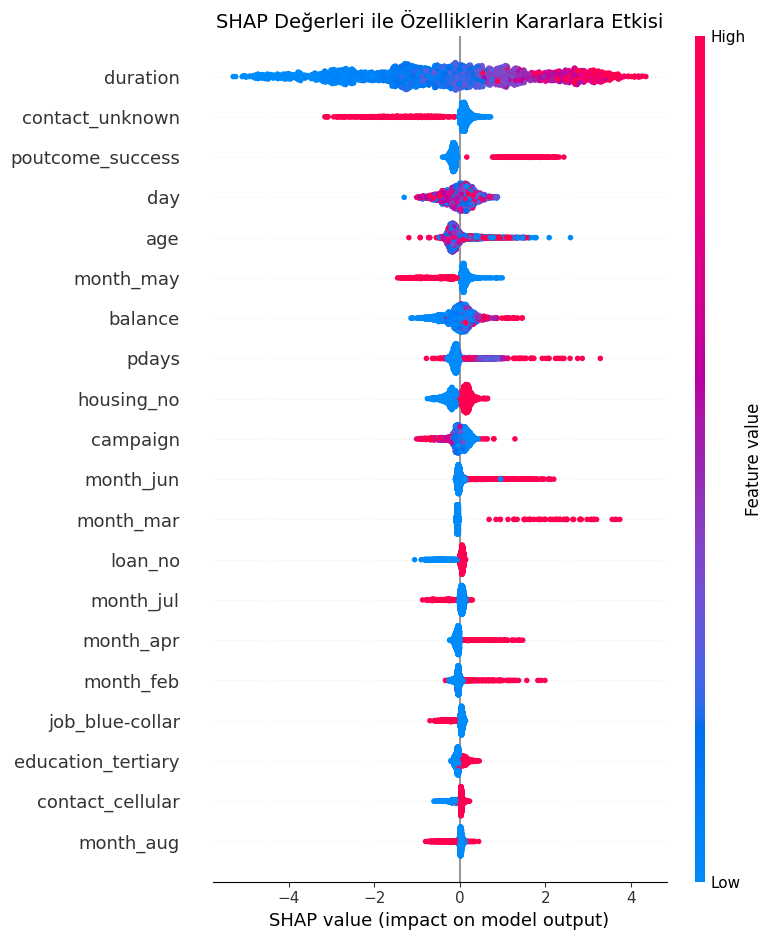

In [13]:
import shap
import matplotlib.pyplot as plt

SHAP_PLOT_WIDTH = 10
SHAP_PLOT_HEIGHT = 6
SHAP_TITLE_FONT_SIZE = 14

preprocessor = final_xgb_pipeline.named_steps['preprocessor']
classifier = final_xgb_pipeline.named_steps['classifier']

X_test_transformed = preprocessor.transform(X_test)

cat_encoder = preprocessor.named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_features)

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_transformed)

plt.figure(figsize=(SHAP_PLOT_WIDTH, SHAP_PLOT_HEIGHT))
plt.title('SHAP Değerleri ile Özelliklerin Kararlara Etkisi', fontsize=SHAP_TITLE_FONT_SIZE)
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.show()

## 6. Sonuç ve Tartışma

Projeden elde edilen bulgular doğrultusunda şu sonuçlara ulaşılmıştır:

* **En İyi Performansı Gösteren Model:** Eğitim ve test seti değerlendirmeleri sonucunda, yönergede de öngörüldüğü üzere karmaşık ilişkileri en iyi yakalayan **XGBoost (Tuned)** modeli en yüksek Accuracy ve AUC skorunu elde etmiştir. Temel (Baseline) model olan Logistic Regression ise daha düşük skorlar üretmesine rağmen hız açısından oldukça verimli çalışmıştır.
* **Hiperparametre Optimizasyonunun Etkisi:** Varsayılan (Default) ayarlarla eğitilen XGBoost ve Random Forest algoritmaları, Optuna ve GridSearchCV işlemleri sonrasında özellikle "Recall" (Gerçek evetleri yakalama oranı) tarafında iyileşme göstermiştir. Bu optimizasyonlar modelin veriyi ezberlemesini (overfitting) engellemiştir.
* **Güçlü ve Zayıf Yönler:** XGBoost doğruluk oranı en yüksek olan güçlü bir model olsa da, Lojistik Regresyon kadar kolay yorumlanabilir değildir (Black-box problemi). Lojistik Regresyon her bir değişkenin etkisini katsayılarla çok net gösterirken, XGBoost için dışarıdan Özellik Önemi (Feature Importance) grafiğine ihtiyaç duyulmuştur.
* **Gelecek Çalışma Önerileri:** Özellik önemi grafiğine bakıldığında `duration` (görüşme süresi) değişkeninin model kararında çok baskın olduğu görülmektedir. Gelecek çalışmalarda, bir müşterinin hesabını açacağı zaten görüşme çok uzun sürdüyse anlaşıldığı için, `duration` değişkeni veri setinden çıkartılarak model eğitilebilir. Böylece model sadece demografik verilere bakarak, müşteriyle **hiç görüşülmeden önce** tahminde bulunmaya zorlanabilir..